<a href="https://colab.research.google.com/github/harishmuh/Computer_Vision_study/blob/main/Cat_vs_non_cat_DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cat or non cat classifier using deep neural network**


![catvsnon](https://datahacker.rs/wp-content/uploads/2018/06/word-image-58.png)

## **Context**

**What is a Deep Neural Network?**

A Deep Neural Network (DNN) is a type of artificial neural network characterized by multiple hidden layers between the input and output layers. This 'depth' allows DNNs to model complex non-linear relationships and learn hierarchical features from data. Each layer in the network transforms the input data into a slightly more abstract and composite representation, enabling the model to understand intricate patterns. In tasks like image classification, early layers might detect simple features like edges, while deeper layers can identify more complex features like shapes or object parts.

**Case: The Cat/Non-Cat Classification Case**

This notebook aims to build a binary image classifier using a deep neural network to distinguish between images that contain a cat and those that do not (non-cat). This is a fundamental problem in computer vision, often used as a 'hello world' equivalent for learning deep learning concepts. The dataset consists of a collection of images, each labeled as either 'cat' (1) or 'non-cat' (0). The goal is to train a model that can accurately predict the label of a new, unseen image. This involves:
1.  **Loading and preprocessing** the image data.
2.  **Building and training** a deep neural network model.
3.  **Evaluating** the model's performance on a test set.
4.  **Making predictions** on new images.

The images are typically represented as numerical pixel values, and the challenge lies in teaching the network to recognize the patterns inherent to cat images versus non-cat images.

We will start by importing the required libraries for the experiment.

**Initial setup**

In [17]:
# Import required libraries
import numpy as np
import copy
import matplotlib.pyplot as plt
import h5py
import scipy

import tensorflow as tf # Deeplearning frame work
from tensorflow import keras # Model building

%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

import warnings
warnings.filterwarnings('ignore')


## **Loading and process dataset**



We will use a dataset ("data.h5") containing:
* a training set of m_train images labelled as cat (1) or non-cat (0)
* a test set of m_test images labelled as cat and non-cat
* each image is of shape (num_px, num_px, 3) where 3 is for the 3 channels (RGB).

In [2]:
# Downloading dataset
!wget https://raw.githubusercontent.com/harishmuh/Deep-Learning-Specialization---Andrew-Ng/main/1.%20Neural%20Networks%20and%20Deep%20Learning/week4/W4A2/datasets/train_catvnoncat.h5
!wget https://raw.githubusercontent.com/harishmuh/Deep-Learning-Specialization---Andrew-Ng/main/1.%20Neural%20Networks%20and%20Deep%20Learning/week4/W4A2/datasets/test_catvnoncat.h5

--2026-04-30 02:14:31--  https://raw.githubusercontent.com/harishmuh/Deep-Learning-Specialization---Andrew-Ng/main/1.%20Neural%20Networks%20and%20Deep%20Learning/week4/W4A2/datasets/train_catvnoncat.h5
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2572022 (2.5M) [application/octet-stream]
Saving to: ‘train_catvnoncat.h5’

train_catvnoncat.h5 100%[===================>]   2.45M  12.2MB/s    in 0.2s    

2026-04-30 02:14:32 (12.2 MB/s) - ‘train_catvnoncat.h5’ saved [2572022/2572022]

--2026-04-30 02:14:32--  https://raw.githubusercontent.com/harishmuh/Deep-Learning-Specialization---Andrew-Ng/main/1.%20Neural%20Networks%20and%20Deep%20Learning/week4/W4A2/datasets/test_catvnoncat.h5
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.

In [3]:
# Loading the data (cat/non-cat)

# Function to load dataset
def load_dataset():
    train_dataset = h5py.File('train_catvnoncat.h5', "r")
    train_set_x_orig = np.array(train_dataset["train_set_x"][:]) # train set features
    train_set_y_orig = np.array(train_dataset["train_set_y"][:]) # train set labels

    test_dataset = h5py.File('test_catvnoncat.h5', "r")
    test_set_x_orig = np.array(test_dataset["test_set_x"][:]) # test set features
    test_set_y_orig = np.array(test_dataset["test_set_y"][:]) # test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes

    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

In [ ]:
# Loading the data (cat/non-cat)
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

y = [1], it's a 'cat' picture.


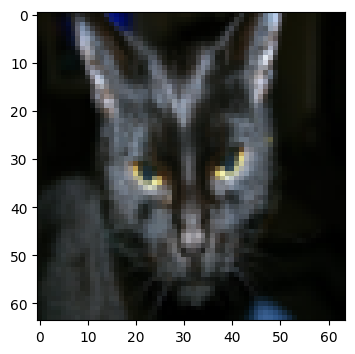

In [6]:
# Example of a picture
index = 25
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", it's a '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") +  "' picture.")

y = 0. It's a non-cat picture.


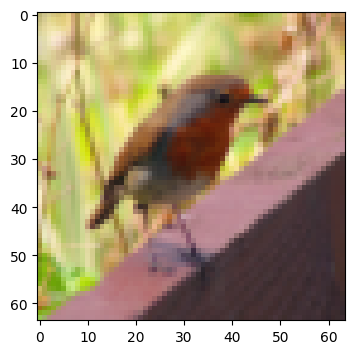

In [9]:
# Example of a picture
index = 10
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[0,index]) + ". It's a " + classes[train_set_y[0,index]].decode("utf-8") +  " picture.")

In [14]:
# Explore the dataset
m_train = train_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[1]
m_test = test_set_x_orig.shape[0]

print ("Number of training examples: " + str(m_train))
print ("Number of testing examples: " + str(m_test))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_x_orig shape: " + str(train_set_x_orig.shape))
print ("train_y shape: " + str(train_set_y.shape))
print ("test_x_orig shape: " + str(test_set_x_orig.shape))
print ("test_y shape: " + str(test_set_y.shape))

Number of training examples: 209
Number of testing examples: 50
Each image is of size: (64, 64, 3)
train_x_orig shape: (209, 64, 64, 3)
train_y shape: (1, 209)
test_x_orig shape: (50, 64, 64, 3)
test_y shape: (1, 50)


We will do standarization

![image](https://raw.githubusercontent.com/harishmuh/Deep-Learning-Specialization---Andrew-Ng/e3b4b727f95a1f3d4fc4c42038c49f5cc33b6811/1.%20Neural%20Networks%20and%20Deep%20Learning/week4/W4A2/images/imvectorkiank.png)
Figure 1. Image to vectors conversion

In [16]:
# Reshape the training and test examples
train_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T   # The "-1" makes reshape flatten the remaining dimensions
test_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T

# Standardize data to have feature values between 0 and 1.
train_x = train_x_flatten/255.
test_x = test_x_flatten/255.

print ("train_x's shape: " + str(train_x.shape))
print ("test_x's shape: " + str(test_x.shape))

train_x's shape: (12288, 209)
test_x's shape: (12288, 50)


## **Model building**

In [19]:
# Model building

tf.random.set_seed(1)

model = tf.keras.models.Sequential([
    keras.layers.Dense(20, activation = "relu"),
    keras.layers.Dense(7, activation = "relu"),
    keras.layers.Dense(5, activation = "relu"),
    keras.layers.Dense(1, activation = "sigmoid")
])

In [20]:
# Compiling model
model.compile(
    loss = keras.losses.BinaryCrossentropy(from_logits = False),
    optimizer = keras.optimizers.SGD(learning_rate = 0.0075),
    metrics = ["accuracy"]
)

## **Model training**

In [24]:
history = model.fit(train_x.T, train_set_y.T, batch_size = 209, epochs = 500, verbose = 2) #batch_size = 209 = number of train examples, to have batch gradient descent

Epoch 1/500
1/1 - 1s - 999ms/step - accuracy: 0.6364 - loss: 0.6937
Epoch 2/500
1/1 - 0s - 85ms/step - accuracy: 0.4306 - loss: 0.7161
Epoch 3/500
1/1 - 0s - 91ms/step - accuracy: 0.5981 - loss: 0.6716
Epoch 4/500
1/1 - 0s - 135ms/step - accuracy: 0.6555 - loss: 0.6491
Epoch 5/500
1/1 - 0s - 91ms/step - accuracy: 0.6555 - loss: 0.6409
Epoch 6/500
1/1 - 0s - 82ms/step - accuracy: 0.6555 - loss: 0.6347
Epoch 7/500
1/1 - 0s - 94ms/step - accuracy: 0.6507 - loss: 0.6310
Epoch 8/500
1/1 - 0s - 136ms/step - accuracy: 0.6555 - loss: 0.6284
Epoch 9/500
1/1 - 0s - 79ms/step - accuracy: 0.6555 - loss: 0.6262
Epoch 10/500
1/1 - 0s - 82ms/step - accuracy: 0.6507 - loss: 0.6259
Epoch 11/500
1/1 - 0s - 90ms/step - accuracy: 0.6555 - loss: 0.6292
Epoch 12/500
1/1 - 0s - 122ms/step - accuracy: 0.6651 - loss: 0.6262
Epoch 13/500
1/1 - 0s - 97ms/step - accuracy: 0.6555 - loss: 0.6226
Epoch 14/500
1/1 - 0s - 84ms/step - accuracy: 0.6603 - loss: 0.6105
Epoch 15/500
1/1 - 0s - 146ms/step - accuracy: 0.6555

## **Model evaluation**

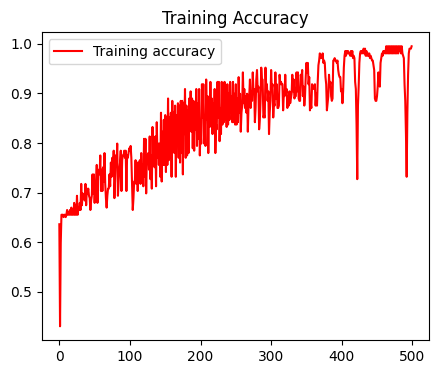

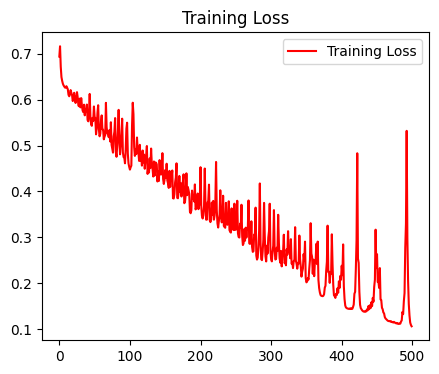

In [26]:
# Plot Accuracy and Loss
import matplotlib.pyplot as plt
acc = history.history['accuracy']
loss = history.history['loss']

epochs = range(len(acc))

# Plot Training Accuracy
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.title('Training Accuracy')
plt.legend(loc=0)
plt.figure() # Create a new figure for the loss plot

# Plot Training Loss
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.title('Training Loss')
plt.legend(loc=0)

plt.show()

In [28]:
# Model evaluation
test_loss, test_acc = model.evaluate(test_x.T, test_set_y.T, verbose=2)
print(f'Accuracy: {test_acc:.4f}')

2/2 - 0s - 127ms/step - accuracy: 0.7800 - loss: 0.6327
Accuracy: 0.7800


We get accuracy score of 0.78 on the testing dataset. Actually this score can be further improved by various measures like adding more layers to increase complexity, conducting data augmentation, using more suitable model for image classification like CNN, implementing regularization and earlystopping, etc.

## **Prediction simulation**

Let's simulate by uploading photos of cat and non-cat (may be your own photo).

Saving kucing_itb_1.JPG to kucing_itb_1.JPG


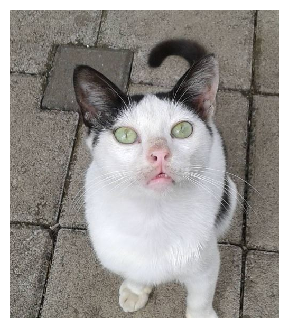

Model prediction: cat (Probability: 0.9732)


In [31]:
# Upload, display uploaded image, and predict
import io
from PIL import Image
from google.colab import files
from keras.preprocessing import image

uploaded = files.upload()  # Upload image manually

for fn in uploaded.keys():

  # ---------- DISPLAY IMAGE ----------
  image_bytes = uploaded[fn]  # Get image bytes

  img_display = Image.open(io.BytesIO(image_bytes)).convert("RGB")
  plt.imshow(img_display)
  plt.axis('off')
  plt.show()

  # ---------- PREPROCESS FOR MODEL ----------
  path = fn
  # Resize image to the expected num_px (64, 64) as used during training
  img = image.load_img(path, target_size=(num_px, num_px))
  x = image.img_to_array(img)  # Convert to numpy array (shape: 64, 64, 3)
  x = x / 255.0  # Normalize
  # Flatten the image and add a batch dimension to match model input (1, 12288)
  x = x.reshape(1, -1)

  # ---------- PREDICT ----------
  # Pass the preprocessed image 'x' directly to the model
  predictions = model.predict(x, verbose=0)
  prediction_probability = predictions[0][0]

  # ---------- CONVERT TO LABEL ----------
  # 'classes' variable is available from load_dataset(), which is [b'non-cat', b'cat']
  # Map the probability to a label (0 for non-cat, 1 for cat)
  if prediction_probability > 0.5:
    predicted_label = classes[1].decode("utf-8") # Index 1 is 'cat'
  else:
    predicted_label = classes[0].decode("utf-8") # Index 0 is 'non-cat'

  print(f"Model prediction: {predicted_label} (Probability: {prediction_probability:.4f})")


The model has predicted the uploaded image correctly.

Saving Capture.JPG to Capture.JPG


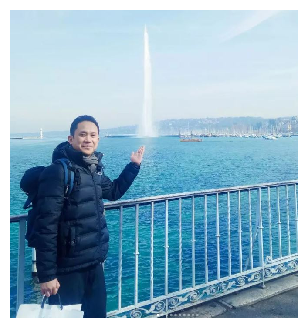

Model prediction: non-cat (Probability: 0.1228)


In [33]:
# Upload, display uploaded image, and predict
import io
from PIL import Image
from google.colab import files
from keras.preprocessing import image

uploaded = files.upload()  # Upload image manually

for fn in uploaded.keys():

  # ---------- DISPLAY IMAGE ----------
  image_bytes = uploaded[fn]  # Get image bytes

  img_display = Image.open(io.BytesIO(image_bytes)).convert("RGB")
  plt.imshow(img_display)
  plt.axis('off')
  plt.show()

  # ---------- PREPROCESS FOR MODEL ----------
  path = fn
  # Resize image to the expected num_px (64, 64) as used during training
  img = image.load_img(path, target_size=(num_px, num_px))
  x = image.img_to_array(img)  # Convert to numpy array (shape: 64, 64, 3)
  x = x / 255.0  # Normalize
  # Flatten the image and add a batch dimension to match model input (1, 12288)
  x = x.reshape(1, -1)

  # ---------- PREDICT ----------
  # Pass the preprocessed image 'x' directly to the model
  predictions = model.predict(x, verbose=0)
  prediction_probability = predictions[0][0]

  # ---------- CONVERT TO LABEL ----------
  # 'classes' variable is available from load_dataset(), which is [b'non-cat', b'cat']
  # Map the probability to a label (0 for non-cat, 1 for cat)
  if prediction_probability > 0.5:
    predicted_label = classes[1].decode("utf-8") # Index 1 is 'cat'
  else:
    predicted_label = classes[0].decode("utf-8") # Index 0 is 'non-cat'

  print(f"Model prediction: {predicted_label} (Probability: {prediction_probability:.4f})")


## **Conclusion**

In this notebook, we successfully built and trained a deep neural network to classify images as either 'cat' or 'non-cat'. We have covered topics such as:

1.  **Data Loading and Preprocessing:** We loaded the dataset, explored its structure, and preprocessed the images by reshaping and standardizing their pixel values.
2.  **Model Building:** We constructed a simple sequential deep neural network using TensorFlow/Keras with multiple dense layers and appropriate activation functions.
3.  **Model Training:** The model was compiled with binary cross-entropy loss and an SGD optimizer, and then trained for 500 epochs.
4.  **Model Evaluation:** We visualized the training accuracy and loss, and evaluated the model's performance on a held-out test set, achieving an accuracy of 78%.
5.  **Prediction Simulation:** We demonstrated how to use the trained model to predict whether a new, uploaded image contains a cat or not.

While the model achieved a reasonable accuracy, we also identified several potential areas for improvement, such as adopting Convolutional Neural Networks (CNNs), performing data augmentation, and experimenting with different hyperparameters or regularization techniques to further enhance performance and generalization.